In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import linregress
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load data
nav = pd.read_csv("../data/processed/clean_nav.csv")
fund_master = pd.read_csv("../data/raw/fund_master.csv")
benchmark = pd.read_csv("../data/raw/benchmark_indices.csv")

# Convert dates
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Sort by date
nav = nav.sort_values("date")
benchmark = benchmark.sort_values("date")

print(" Data loaded successfully")
print(f"  nav shape: {nav.shape}")
print(f"  fund_master shape: {fund_master.shape}")
print(f"  benchmark shape: {benchmark.shape}")
print(f"  benchmark columns: {benchmark.columns.tolist()}")

 Data loaded successfully
  nav shape: (46000, 3)
  fund_master shape: (40, 15)
  benchmark shape: (8050, 3)
  benchmark columns: ['date', 'index_name', 'close_value']


In [8]:
# Task 1: Compute daily returns for all funds

# Convert date column (your NAV data uses date, not nav_date)
nav_sorted = nav.sort_values(["amfi_code", "date"])


# Calculate daily returns per fund
nav_sorted["daily_return"] = nav_sorted.groupby("amfi_code")["nav"].pct_change()


# Calculate annualised return per fund
def annualised_return(returns):
    """Calculate annualised return using compound growth"""

    valid_returns = returns.dropna()

    if len(valid_returns) == 0:
        return 0

    return (1 + valid_returns).prod() ** (252 / len(valid_returns)) - 1



annualised_returns = (
    nav_sorted
    .groupby("amfi_code")["daily_return"]
    .apply(annualised_return)
    .reset_index()
)


# Create dataframe
returns_computed = pd.DataFrame({

    "amfi_code": annualised_returns["amfi_code"],

    "annualised_return_pct":
        (annualised_returns["daily_return"] * 100).round(2)

})


# Merge fund details
returns_computed = returns_computed.merge(
    fund_master[["amfi_code", "scheme_name", "fund_house"]],
    on="amfi_code",
    how="left"
)


# Save output
returns_computed.to_csv(
    "../data/processed/returns_computed.csv",
    index=False
)


print("Task 1 Complete: Daily Returns Computed")
print(f"   Total funds: {len(returns_computed)}")

print("\n   Top 5 funds by annualised return:")
print(
    returns_computed
    .nlargest(5, "annualised_return_pct")
    [["scheme_name", "annualised_return_pct"]]
)
print("\n   Bottom 5 funds by annualised return:")
print(
    returns_computed
    .nsmallest(5, "annualised_return_pct")
    [["scheme_name", "annualised_return_pct"]]
)

Task 1 Complete: Daily Returns Computed
   Total funds: 40

   Top 5 funds by annualised return:
                                      scheme_name  annualised_return_pct
25       ICICI Pru Midcap Fund - Regular - Growth                  31.51
21     SBI Small Cap Fund - Regular Plan - Growth                  31.13
39          DSP Small Cap Fund - Regular - Growth                  31.00
36  Mirae Asset Tax Saver Fund - Regular - Growth                  30.67
34  Mirae Asset Large Cap Fund - Regular - Growth                  29.74

   Bottom 5 funds by annualised return:
                                     scheme_name  annualised_return_pct
7            UTI Mid Cap Fund - Regular - Growth                   1.13
17        Axis Small Cap Fund - Regular - Growth                   1.47
22     SBI Small Cap Fund - Direct Plan - Growth                   1.98
0      HDFC Top 100 Fund - Regular Plan - Growth                   2.54
1   HDFC Short Term Debt Fund - Regular - Growth                

In [9]:
# Task 2: Calculate CAGR for 1yr, 3yr, 5yr periods
def calculate_cagr(nav_series, years):
    """Calculate CAGR for specified years"""
    nav_series = nav_series.dropna()
    if len(nav_series) < 2:
        return np.nan
    start_nav = nav_series.iloc[0]
    end_nav = nav_series.iloc[-1]
    if start_nav <= 0:
        return np.nan
    cagr = (end_nav / start_nav) ** (1 / years) - 1
    return cagr * 100

cagr_data = []
for code in nav_sorted["amfi_code"].unique():

    # NAV data uses date column
    fund_nav = nav_sorted[
        nav_sorted["amfi_code"] == code
    ].sort_values("date")

    if len(fund_nav) < 2:
        continue

    scheme_name = fund_master[fund_master["amfi_code"] == code]["scheme_name"].values
    fund_house = fund_master[fund_master["amfi_code"] == code]["fund_house"].values
    # 1 year CAGR (last 252 trading days)
    cagr_1yr = calculate_cagr(fund_nav["nav"].tail(252),1)
    # 3 year CAGR (last 756 trading days)
    cagr_3yr = calculate_cagr(fund_nav["nav"].tail(756),3)
    # 5 year CAGR (last 1260 trading days)
    cagr_5yr = calculate_cagr(fund_nav["nav"].tail(1260),5)
    cagr_data.append({

        "amfi_code": code,

        "scheme_name":
            scheme_name[0]
            if len(scheme_name) > 0
            else "",

        "fund_house":
            fund_house[0]
            if len(fund_house) > 0
            else "",

        "cagr_1yr_pct":
            round(cagr_1yr, 2)
            if not np.isnan(cagr_1yr)
            else np.nan,

        "cagr_3yr_pct":
            round(cagr_3yr, 2)
            if not np.isnan(cagr_3yr)
            else np.nan,

        "cagr_5yr_pct":
            round(cagr_5yr, 2)
            if not np.isnan(cagr_5yr)
            else np.nan
    })


# Create CAGR report
cagr_report = pd.DataFrame(cagr_data)

# Save file
cagr_report.to_csv(
    "../data/processed/cagr_report.csv",
    index=False
)

print(" Task 2 Complete: CAGR Calculated")
print(f"   Funds analyzed: {len(cagr_report)}")
print("\n   Top 5 funds by 3-year CAGR:")
print(cagr_report.nlargest(5, "cagr_3yr_pct")[["scheme_name","cagr_1yr_pct","cagr_3yr_pct","cagr_5yr_pct"]])

 Task 2 Complete: CAGR Calculated
   Funds analyzed: 40

   Top 5 funds by 3-year CAGR:
                                          scheme_name  cagr_1yr_pct  \
16                Axis Midcap Fund - Regular - Growth         30.92   
2   HDFC Mid-Cap Opportunities Fund - Regular - Gr...         47.73   
3       ABSL Frontline Equity Fund - Regular - Growth         45.09   
34      Mirae Asset Large Cap Fund - Regular - Growth         14.58   
25           ICICI Pru Midcap Fund - Regular - Growth         30.35   

    cagr_3yr_pct  cagr_5yr_pct  
16         36.07         24.45  
2          33.63         26.07  
3          32.53         20.44  
34         31.28         26.80  
25         30.21         28.38  


In [10]:
# Task 3: Compute Sharpe Ratio
RF = 6.5 / 100  # Risk-free rate (RBI repo rate)
sharpe_data = []
for code in nav_sorted["amfi_code"].unique():

    fund_nav = nav_sorted[nav_sorted["amfi_code"] == code].sort_values("date")
    returns = fund_nav["daily_return"].dropna()

    if len(returns) < 2:
        continue

    scheme_name = fund_master[fund_master["amfi_code"] == code]["scheme_name"].values
    fund_house = fund_master[fund_master["amfi_code"] == code]["fund_house"].values

    # Annualised return
    annual_return = (1 + returns).prod() ** (252 / len(returns)) - 1

    # Annualised volatility
    annual_volatility = returns.std() * np.sqrt(252)

    # Sharpe ratio
    sharpe = (annual_return - RF) / annual_volatility if annual_volatility > 0 else 0

    sharpe_data.append({
        "amfi_code": code,
        "scheme_name": scheme_name[0] if len(scheme_name) > 0 else "",
        "fund_house": fund_house[0] if len(fund_house) > 0 else "",
        "annual_return_pct": round(annual_return * 100, 2),
        "annual_volatility_pct": round(annual_volatility * 100, 2),
        "sharpe_ratio": round(sharpe, 3)
    })

sharpe_values = pd.DataFrame(sharpe_data)

sharpe_values.to_csv("../data/processed/sharpe_values.csv", index=False)

print(" Task 3 Complete: Sharpe Ratio Computed")
print(f"   Risk-free rate used: {RF*100}%")

print("\n   Top 5 funds by Sharpe Ratio:")
print(sharpe_values.nlargest(5, "sharpe_ratio")[["scheme_name", "annual_return_pct", "annual_volatility_pct", "sharpe_ratio"]])

print("\n   Sharpe statistics:")
print(f"   Mean: {sharpe_values['sharpe_ratio'].mean():.3f}")
print(f"   Median: {sharpe_values['sharpe_ratio'].median():.3f}")
print(f"   Std Dev: {sharpe_values['sharpe_ratio'].std():.3f}")

 Task 3 Complete: Sharpe Ratio Computed
   Risk-free rate used: 6.5%

   Top 5 funds by Sharpe Ratio:
                                      scheme_name  annual_return_pct  \
34  Mirae Asset Large Cap Fund - Regular - Growth              29.74   
30         Kotak Flexicap Fund - Regular - Growth              29.68   
36  Mirae Asset Tax Saver Fund - Regular - Growth              30.67   
19      SBI Bluechip Fund - Regular Plan - Growth              24.80   
25       ICICI Pru Midcap Fund - Regular - Growth              31.51   

    annual_volatility_pct  sharpe_ratio  
34                  14.19         1.637  
30                  15.89         1.459  
36                  17.67         1.368  
19                  13.74         1.331  
25                  19.29         1.297  

   Sharpe statistics:
   Mean: 0.586
   Median: 0.669
   Std Dev: 0.611


In [11]:
# Task 4: Compute Sortino Ratio
RF = 6.5 / 100  # Risk-free rate
sortino_data = []
for code in nav_sorted["amfi_code"].unique():

    fund_nav = nav_sorted[nav_sorted["amfi_code"] == code].sort_values("date")
    returns = fund_nav["daily_return"].dropna()
    
    if len(returns) < 2:
        continue
    
    scheme_name = fund_master[fund_master["amfi_code"] == code]["scheme_name"].values
    fund_house = fund_master[fund_master["amfi_code"] == code]["fund_house"].values
    
    # Annualised return
    annual_return = (1 + returns).prod() ** (252 / len(returns)) - 1
    
    # Downside deviation (only negative returns)
    downside_returns = returns[returns < 0]
    downside_volatility = downside_returns.std() * np.sqrt(252) if len(downside_returns) > 0 else 0
    
    # Sortino ratio
    sortino = (annual_return - RF) / downside_volatility if downside_volatility > 0 else 0
    
    sortino_data.append({
        "amfi_code": code,
        "scheme_name": scheme_name[0] if len(scheme_name) > 0 else "",
        "fund_house": fund_house[0] if len(fund_house) > 0 else "",
        "downside_volatility_pct": round(downside_volatility * 100, 2),
        "sortino_ratio": round(sortino, 3)
    })

sortino_values = pd.DataFrame(sortino_data)

sortino_values.to_csv("../data/processed/sortino_values.csv", index=False)

print("Task 4 Complete: Sortino Ratio Computed")
print("\n   Top 5 funds by Sortino Ratio:")
print(sortino_values.nlargest(5, "sortino_ratio")[["scheme_name", "downside_volatility_pct", "sortino_ratio"]])

Task 4 Complete: Sortino Ratio Computed

   Top 5 funds by Sortino Ratio:
                                      scheme_name  downside_volatility_pct  \
34  Mirae Asset Large Cap Fund - Regular - Growth                     8.62   
30         Kotak Flexicap Fund - Regular - Growth                     8.78   
36  Mirae Asset Tax Saver Fund - Regular - Growth                    10.17   
19      SBI Bluechip Fund - Regular Plan - Growth                     7.76   
25       ICICI Pru Midcap Fund - Regular - Growth                    11.22   

    sortino_ratio  
34          2.697  
30          2.640  
36          2.378  
19          2.359  
25          2.230  


In [16]:
# Task 5: Compute Alpha & Beta vs Nifty 100
benchmark["date"] = pd.to_datetime(benchmark["date"])
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].sort_values("date")
nifty100["nifty100_return"] = nifty100["close_value"].pct_change()
alpha_beta_data = []

for code in nav_sorted["amfi_code"].unique():
    fund_nav = nav_sorted[nav_sorted["amfi_code"] == code].sort_values("date")
    
    if len(fund_nav) < 252:
        continue
    
    scheme_name = fund_master[fund_master["amfi_code"] == code]["scheme_name"].values
    fund_house = fund_master[fund_master["amfi_code"] == code]["fund_house"].values
    
    merged = pd.merge(
        fund_nav[["date", "daily_return"]],
        nifty100[["date", "nifty100_return"]],
        on="date",
        how="inner"
    ).dropna()
    
    if len(merged) < 252:
        continue
    
    fund_returns = merged["daily_return"]
    benchmark_returns = merged["nifty100_return"]
    
    slope, intercept, r_value, p_value, std_err = linregress(benchmark_returns, fund_returns)
    
    alpha = intercept * 252 * 100
    beta = slope
    r_squared = r_value ** 2
    
    alpha_beta_data.append({
        "amfi_code": code,
        "scheme_name": scheme_name[0] if len(scheme_name) > 0 else "",
        "fund_house": fund_house[0] if len(fund_house) > 0 else "",
        "alpha_pct": round(alpha, 2),
        "beta": round(beta, 3),
        "r_squared": round(r_squared, 3)
    })

alpha_beta = pd.DataFrame(alpha_beta_data)
alpha_beta.to_csv("../data/processed/alpha_beta.csv", index=False)

print(" Task 5 Complete: Alpha & Beta Computed")
print(f"   Funds analyzed: {len(alpha_beta)}")
print("\n   Top 5 funds by Alpha:")
print(alpha_beta.nlargest(5, "alpha_pct")[["scheme_name", "alpha_pct", "beta", "r_squared"]])

 Task 5 Complete: Alpha & Beta Computed
   Funds analyzed: 40

   Top 5 funds by Alpha:
                                      scheme_name  alpha_pct   beta  r_squared
21     SBI Small Cap Fund - Regular Plan - Growth      30.34 -0.023        0.0
39          DSP Small Cap Fund - Regular - Growth      30.06  0.011        0.0
25       ICICI Pru Midcap Fund - Regular - Growth      29.26  0.001        0.0
36  Mirae Asset Tax Saver Fund - Regular - Growth      28.27  0.018        0.0
30         Kotak Flexicap Fund - Regular - Growth      27.33 -0.023        0.0


In [17]:
# Task 6: Compute Maximum Drawdown

def calculate_max_drawdown(nav_series):
    """Calculate maximum drawdown"""
    cummax = np.maximum.accumulate(nav_series)
    drawdown = (nav_series - cummax) / cummax
    return drawdown.min() * 100

def find_drawdown_period(nav_series, date_series):
    """Find worst drawdown period"""
    cummax = np.maximum.accumulate(nav_series)
    drawdown = (nav_series - cummax) / cummax
    worst_idx = drawdown.argmin()
    
    if worst_idx == 0:
        return None, None, drawdown.min() * 100
    
    peak_idx = np.argmax(nav_series[:worst_idx])
    
    if peak_idx < worst_idx:
        start_date = date_series.iloc[peak_idx]
        end_date = date_series.iloc[worst_idx]
        return start_date, end_date, drawdown.min() * 100
    
    return None, None, drawdown.min() * 100


drawdown_data = []

for code in nav_sorted["amfi_code"].unique():
    fund_nav = nav_sorted[nav_sorted["amfi_code"] == code].sort_values("date")
    
    if len(fund_nav) < 2:
        continue
    
    scheme_name = fund_master[fund_master["amfi_code"] == code]["scheme_name"].values
    fund_house = fund_master[fund_master["amfi_code"] == code]["fund_house"].values
    
    max_dd = calculate_max_drawdown(fund_nav["nav"].values)
    
    start_date, end_date, dd_pct = find_drawdown_period(
        fund_nav["nav"].values,
        fund_nav["date"]
    )
    
    drawdown_data.append({
        "amfi_code": code,
        "scheme_name": scheme_name[0] if len(scheme_name) > 0 else "",
        "fund_house": fund_house[0] if len(fund_house) > 0 else "",
        "max_drawdown_pct": round(max_dd, 2),
        "worst_dd_start_date": start_date,
        "worst_dd_end_date": end_date
    })


max_drawdown = pd.DataFrame(drawdown_data)

max_drawdown.to_csv("../data/processed/max_drawdown.csv", index=False)

print("Task 6 Complete: Maximum Drawdown Computed")
print(f"   Funds analyzed: {len(max_drawdown)}")

print("\n   Funds with worst drawdowns:")
print(max_drawdown.nsmallest(5, "max_drawdown_pct")[["scheme_name", "max_drawdown_pct", "worst_dd_start_date", "worst_dd_end_date"]])

print(f"\n   Average max drawdown: {max_drawdown['max_drawdown_pct'].mean():.2f}%")

Task 6 Complete: Maximum Drawdown Computed
   Funds analyzed: 40

   Funds with worst drawdowns:
                                   scheme_name  max_drawdown_pct  \
22   SBI Small Cap Fund - Direct Plan - Growth            -52.57   
17      Axis Small Cap Fund - Regular - Growth            -51.68   
4       ABSL Small Cap Fund - Regular - Growth            -35.45   
39       DSP Small Cap Fund - Regular - Growth            -31.17   
21  SBI Small Cap Fund - Regular Plan - Growth            -28.71   

   worst_dd_start_date worst_dd_end_date  
22          2023-01-17        2025-10-28  
17          2025-05-22        2026-05-11  
4           2024-11-21        2026-05-11  
39          2024-05-03        2025-01-03  
21          2024-08-28        2025-05-14  

   Average max drawdown: -17.87%


In [19]:
# Task 7: Build Fund Scorecard (composite ranking)

# Merge all metrics
scorecard = fund_master[["amfi_code", "scheme_name", "fund_house", "category", "expense_ratio_pct"]].copy()
# Merge CAGR
scorecard = scorecard.merge(cagr_report[["amfi_code", "cagr_3yr_pct"]], on="amfi_code", how="left")
# Merge Sharpe
scorecard = scorecard.merge(sharpe_values[["amfi_code", "sharpe_ratio"]], on="amfi_code", how="left")
# Merge Alpha
scorecard = scorecard.merge(alpha_beta[["amfi_code", "alpha_pct"]], on="amfi_code", how="left")
# Merge Max Drawdown
scorecard = scorecard.merge(max_drawdown[["amfi_code", "max_drawdown_pct"]], on="amfi_code", how="left")

# Calculate ranks (higher is better for returns/sharpe/alpha, lower is better for expense ratio/drawdown)
scorecard["return_rank"] = scorecard["cagr_3yr_pct"].rank(method="min")
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(method="min")
scorecard["alpha_rank"] = scorecard["alpha_pct"].rank(method="min")
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(method="min", ascending=False)  # Inverse
scorecard["dd_rank"] = scorecard["max_drawdown_pct"].rank(method="min", ascending=False)  # Inverse (less drawdown = better)

# Calculate composite score: 30% return + 25% Sharpe + 20% Alpha + 15% Expense + 10% Drawdown
scorecard["composite_score"] = (
    0.30 * scorecard["return_rank"] +
    0.25 * scorecard["sharpe_rank"] +
    0.20 * scorecard["alpha_rank"] +
    0.15 * scorecard["expense_rank"] +
    0.10 * scorecard["dd_rank"]
)

# Normalize to 0-100 scale
min_score = scorecard["composite_score"].min()
max_score = scorecard["composite_score"].max()
scorecard["final_score_0_100"] = ((scorecard["composite_score"] - min_score) / (max_score - min_score)) * 100

# Save
scorecard_export = scorecard[[
    "amfi_code", "scheme_name", "fund_house", "category", 
    "cagr_3yr_pct", "sharpe_ratio", "alpha_pct", 
    "expense_ratio_pct", "max_drawdown_pct", "final_score_0_100"
]].sort_values("final_score_0_100", ascending=False)

scorecard_export.to_csv("../data/processed/fund_scorecard.csv", index=False)

print(" Task 7 Complete: Fund Scorecard Built")
print(f"   Total funds scored: {len(scorecard_export)}")
print(f"\n   Top 10 funds by Composite Score:")
print(scorecard_export.head(10)[["scheme_name", "category", "cagr_3yr_pct", "sharpe_ratio", "final_score_0_100"]])
print(f"\n   Bottom 5 funds by Composite Score:")
print(scorecard_export.tail(5)[["scheme_name", "category", "cagr_3yr_pct", "sharpe_ratio", "final_score_0_100"]])

 Task 7 Complete: Fund Scorecard Built
   Total funds scored: 40

   Top 10 funds by Composite Score:
                                          scheme_name category  cagr_3yr_pct  \
12           ICICI Pru Midcap Fund - Regular - Growth   Equity         30.21   
7   HDFC Mid-Cap Opportunities Fund - Regular - Gr...   Equity         33.63   
26                Axis Midcap Fund - Regular - Growth   Equity         36.07   
34      Mirae Asset Large Cap Fund - Regular - Growth   Equity         31.28   
2          SBI Small Cap Fund - Regular Plan - Growth   Equity         27.81   
22             Kotak Flexicap Fund - Regular - Growth   Equity         25.66   
39              DSP Small Cap Fund - Regular - Growth   Equity         25.03   
11          ICICI Pru Bluechip Fund - Direct - Growth   Equity         28.37   
0           SBI Bluechip Fund - Regular Plan - Growth   Equity         27.73   
36      Mirae Asset Tax Saver Fund - Regular - Growth   Equity         23.32   

    sharpe_ratio 

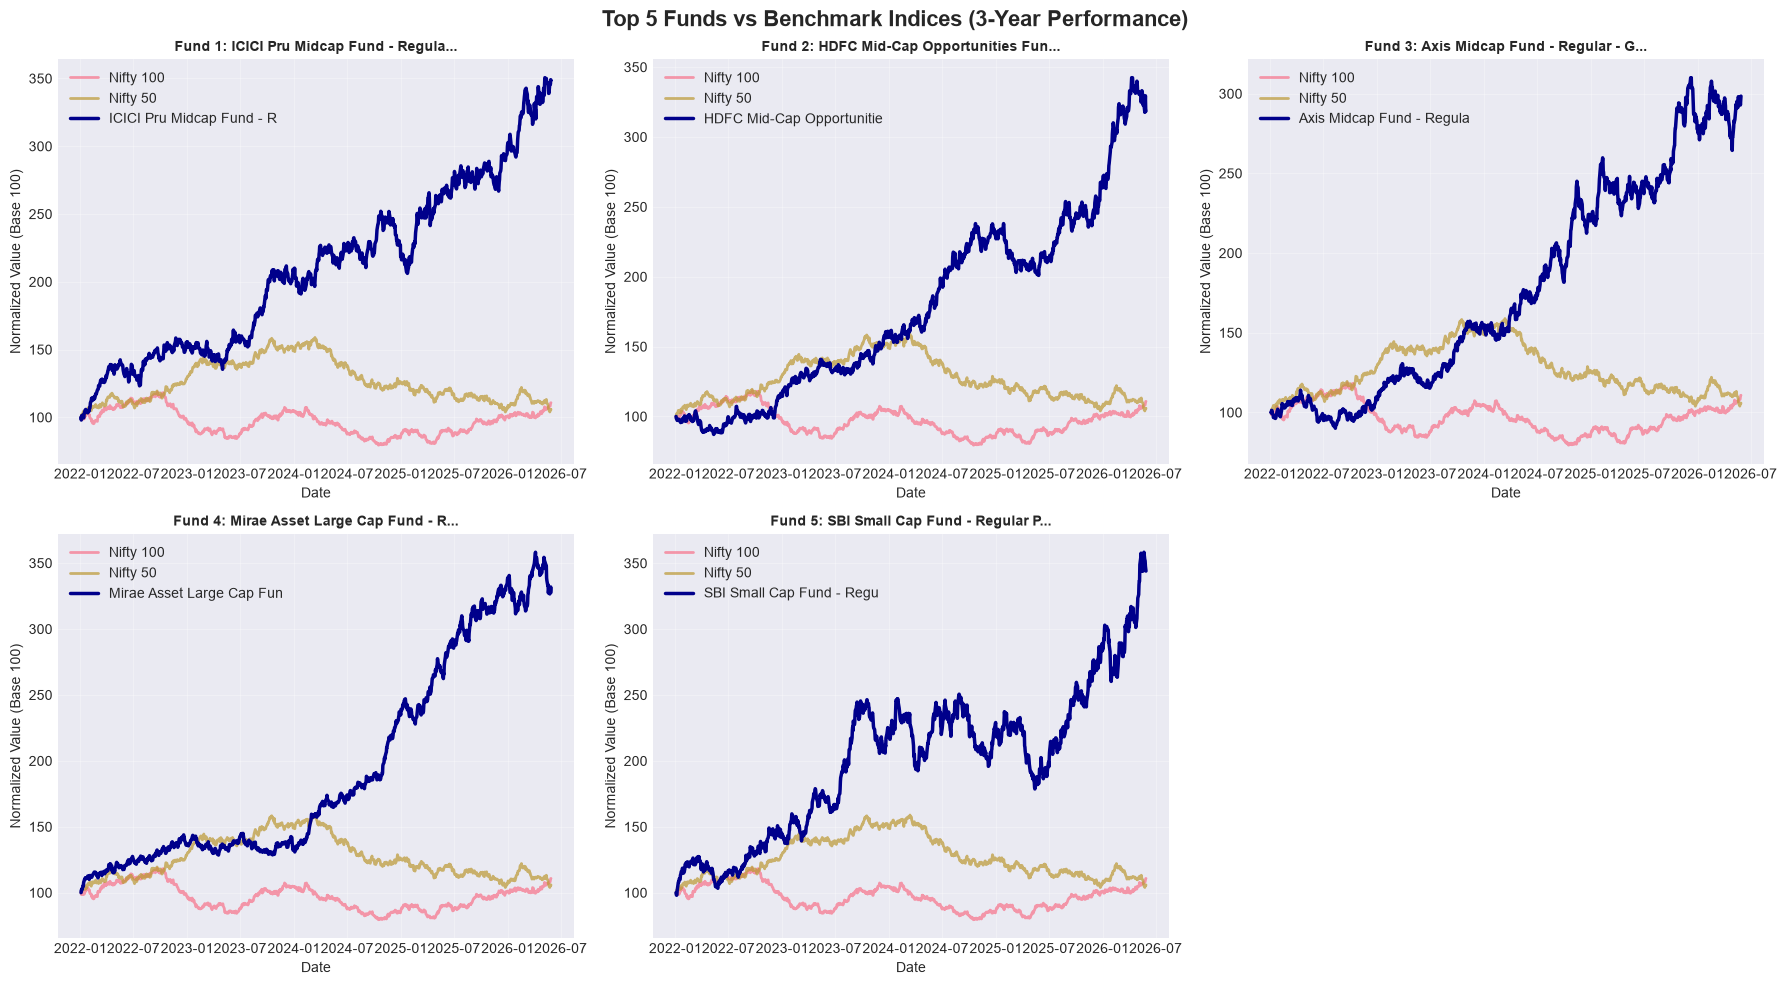

 Task 8 Complete: Benchmark Comparison Chart

   Tracking Error Analysis (vs Nifty 100):
   ICICI Pru Midcap Fund - Regular - Growth TE: 23.19%
   HDFC Mid-Cap Opportunities Fund - Regula TE: 22.86%
   Axis Midcap Fund - Regular - Growth      TE: 23.75%
   Mirae Asset Large Cap Fund - Regular - G TE: 18.96%
   SBI Small Cap Fund - Regular Plan - Grow TE: 28.38%


In [22]:
# Task 8: Benchmark comparison - Top 5 funds vs Nifty 50 & Nifty 100
# Get top 5 funds by CAGR
top_5_funds = scorecard_export.head(5)["amfi_code"].values
# Prepare benchmark data
benchmark["date"] = pd.to_datetime(benchmark["date"])
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].sort_values("date")
nifty50 = benchmark[benchmark["index_name"] == "NIFTY50"].sort_values("date")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Top 5 Funds vs Benchmark Indices (3-Year Performance)", fontsize=16, fontweight="bold")

for idx, code in enumerate(top_5_funds):

    ax = axes[idx // 3, idx % 3]

    fund_data = nav_sorted[nav_sorted["amfi_code"] == code].sort_values("date")

    scheme_name = fund_master[fund_master["amfi_code"] == code]["scheme_name"].values[0]
    # Normalize fund
    fund_norm = (fund_data["nav"] / fund_data["nav"].iloc[0]) * 100
    # Benchmark period
    bench100 = nifty100[nifty100["date"] >= fund_data["date"].min()]
    bench50 = nifty50[nifty50["date"] >= fund_data["date"].min()]
    # Normalize Nifty 100
    if len(bench100) > 0:
        nifty100_norm = (bench100["close_value"] / bench100["close_value"].iloc[0]) * 100
        ax.plot(bench100["date"], nifty100_norm, label="Nifty 100", linewidth=2, alpha=0.7)
    # Normalize Nifty 50
    if len(bench50) > 0:
        nifty50_norm = (bench50["close_value"] / bench50["close_value"].iloc[0]) * 100
        ax.plot(bench50["date"], nifty50_norm, label="Nifty 50", linewidth=2, alpha=0.7)
    ax.plot(fund_data["date"], fund_norm, label=scheme_name[:25], linewidth=2.5, color="darkblue")
    ax.set_title(f"Fund {idx+1}: {scheme_name[:30]}...", fontsize=10, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Normalized Value (Base 100)")
    ax.legend()
    ax.grid(True, alpha=0.3)


axes[1, 2].remove()
plt.tight_layout()
plt.savefig("../reports/04_benchmark_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Tracking error
print(" Task 8 Complete: Benchmark Comparison Chart")
print("\n   Tracking Error Analysis (vs Nifty 100):")
nifty100_returns = nifty100["close_value"].pct_change().dropna()

for code in top_5_funds:

    fund_returns = nav_sorted[
        nav_sorted["amfi_code"] == code
    ]["daily_return"].dropna()


    scheme_name = fund_master[
        fund_master["amfi_code"] == code
    ]["scheme_name"].values[0]


    min_len = min(
        len(fund_returns),
        len(nifty100_returns)
    )


    if min_len > 0:

        tracking_error = (
            fund_returns.iloc[-min_len:].values -
            nifty100_returns.iloc[-min_len:].values
        ).std() * np.sqrt(252) * 100


        print(f"   {scheme_name[:40]:<40} TE: {tracking_error:.2f}%")